# Classification Track — Review 1 (Part A)
**Dataset:** Airline Passenger Satisfaction  
**Target:** `satisfaction` (satisfied / neutral or dissatisfied)  
**Algorithms (Part A):** Logistic Regression, K-Nearest Neighbors, Gaussian Naive Bayes, Decision Tree, Support Vector Machine

This notebook covers: dataset audit, EDA, cleaning, feature engineering, encoding/scaling/splitting,
and training + evaluating the five Part-A classification algorithms with a comparison table.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (8, 5)


## Section A — Dataset Audit & EDA

In [2]:
df = pd.read_csv("airlinepassenger.csv")
df = df.drop(columns=[c for c in ["Unnamed: 0", "id"] if c in df.columns])

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nTarget distribution:\n", df['satisfaction'].value_counts())
print("\nTarget distribution (%):\n", df['satisfaction'].value_counts(normalize=True) * 100)


Shape: (25976, 23)

Dtypes:
 Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes  

**Observation:** The dataset has 25,976 rows and 23 usable columns after dropping the two
identifier columns (`Unnamed: 0`, `id`), which carry no predictive signal and would only add noise
if left in. The only missing values are in `Arrival Delay in Minutes` (83 rows, ~0.3%). The target
classes are reasonably balanced (~55% neutral/dissatisfied vs ~45% satisfied), so no resampling is required.

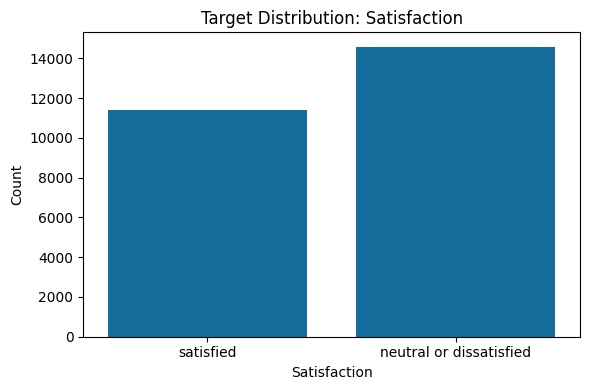

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x='satisfaction', ax=ax)
ax.set_title("Target Distribution: Satisfaction")
ax.set_xlabel("Satisfaction")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("target_distribution.png", bbox_inches="tight")
plt.show()


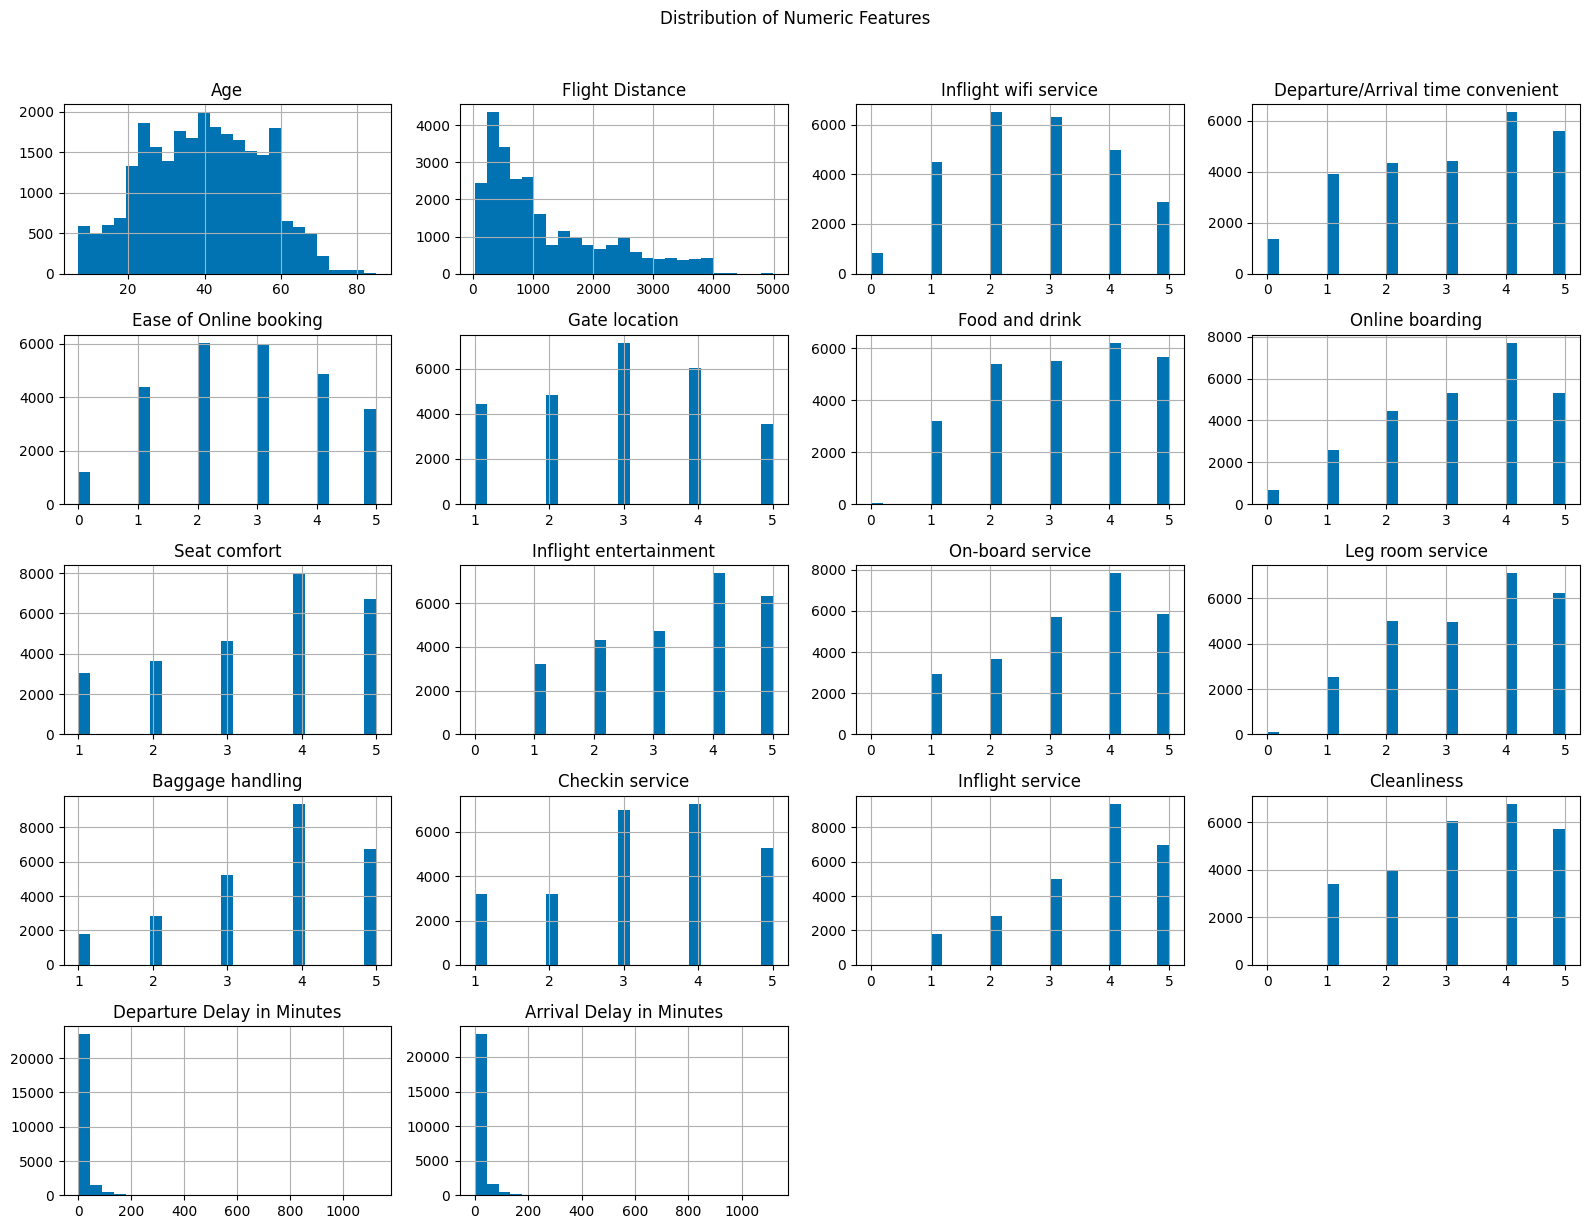

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].hist(figsize=(16, 12), bins=25)
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.tight_layout()
plt.savefig("feature_distributions.png", bbox_inches="tight")
plt.show()


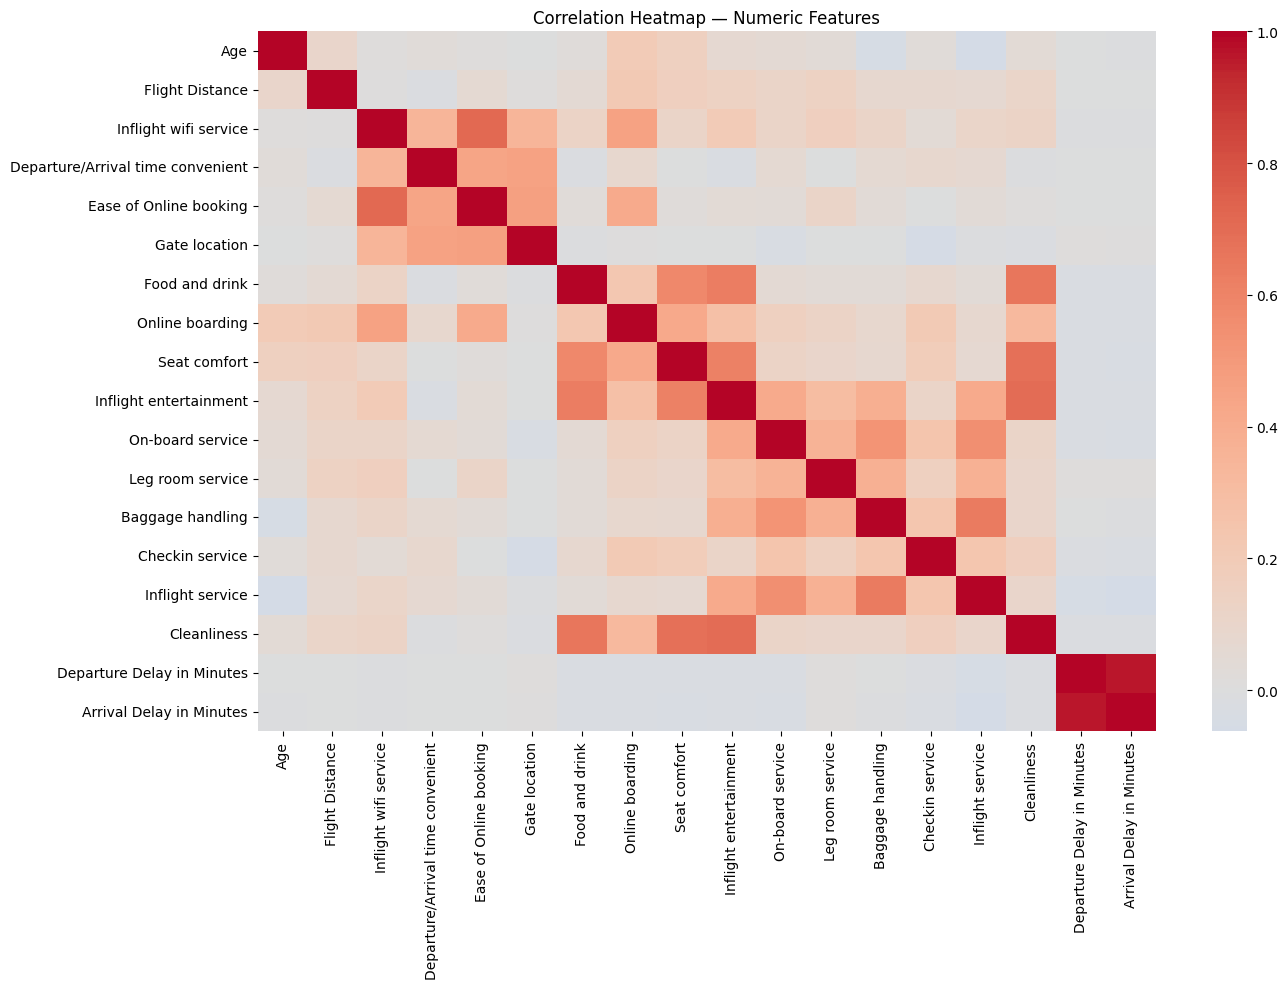

In [5]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()


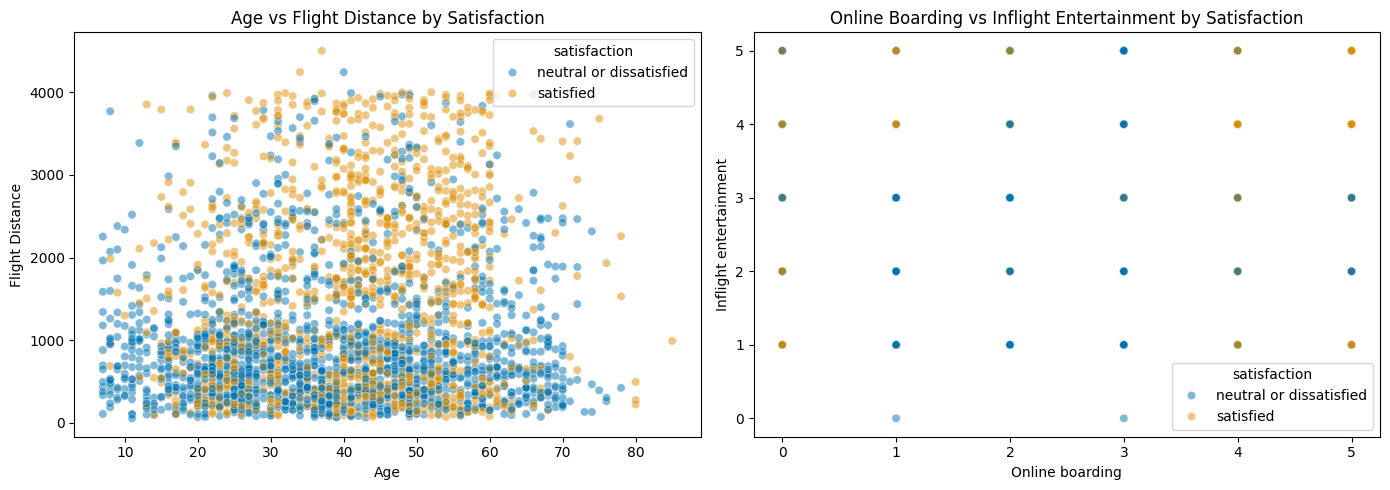

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='Age', y='Flight Distance',
                 hue='satisfaction', alpha=0.5, ax=axes[0])
axes[0].set_title("Age vs Flight Distance by Satisfaction")

sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='Online boarding', y='Inflight entertainment',
                 hue='satisfaction', alpha=0.5, ax=axes[1])
axes[1].set_title("Online Boarding vs Inflight Entertainment by Satisfaction")
plt.tight_layout()
plt.savefig("scatter_relationships.png", bbox_inches="tight")
plt.show()


**Observations:**
- Numeric service-rating features (`Online boarding`, `Inflight entertainment`, `Seat comfort`) are
  ordinal (0–5) and show visibly higher scores associated with `satisfied` passengers in the scatter plots.
- `Departure Delay in Minutes` and `Arrival Delay in Minutes` are heavily right-skewed (most flights have
  little to no delay, with a long tail) — worth noting for outlier handling.
- The correlation heatmap shows `Departure Delay` and `Arrival Delay` are very highly correlated with
  each other (as expected, since one causes the other), which is useful to know before feature engineering.


## Section B — Data Cleaning, Feature Engineering, Encoding & Splitting

In [7]:
# B1: Data cleaning
# Impute missing Arrival Delay with median (robust to the right-skew we saw above)
median_arrival_delay = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_arrival_delay)

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Outlier check on delay columns using IQR
for col in ['Departure Delay in Minutes', 'Arrival Delay in Minutes']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_outliers = (df[col] > upper).sum()
    print(f"{col}: {n_outliers} outlier rows above {upper:.1f} min (capping, not dropping, to keep genuine long-delay cases)")
    df[col] = np.where(df[col] > upper, upper, df[col])

print("\nShape after cleaning:", df.shape)


Duplicate rows: 0
Departure Delay in Minutes: 3569 outlier rows above 30.0 min (capping, not dropping, to keep genuine long-delay cases)
Arrival Delay in Minutes: 3538 outlier rows above 32.5 min (capping, not dropping, to keep genuine long-delay cases)

Shape after cleaning: (25976, 23)


**Justification:** Missing `Arrival Delay` values were imputed with the median rather than the
mean because the distribution is heavily right-skewed (a few very long delays would pull the mean up).
Delay outliers were capped (winsorized) at 1.5×IQR above Q3 rather than dropped, since an unusually long
delay is a genuine, informative data point for a satisfaction model — not a data-entry error.

In [8]:
# B3: Feature engineering
# Engineered feature 1: total delay (captures cumulative disruption to the passenger's journey)
df['Total Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']

# Engineered feature 2: average in-flight service score (single summary of service-quality ratings,
# reduces redundancy across 6 highly correlated ordinal service columns)
service_cols = ['Inflight wifi service', 'Food and drink', 'Seat comfort',
                 'Inflight entertainment', 'On-board service', 'Cleanliness']
df['Avg Service Score'] = df[service_cols].mean(axis=1)

print(df[['Total Delay', 'Avg Service Score']].describe())


        Total Delay  Avg Service Score
count  25976.000000       25976.000000
mean      15.227749           3.236494
std       22.176957           0.895888
min        0.000000           0.833333
25%        0.000000           2.666667
50%        2.000000           3.333333
75%       24.000000           4.000000
max       62.500000           5.000000


**Justification for feature engineering:** `Total Delay` combines departure and arrival delay into
a single disruption measure — since the two are highly correlated (seen in the heatmap), this reduces
redundancy while preserving the signal. `Avg Service Score` condenses six correlated ordinal
service-rating columns into one summary metric, which should help simpler models (Logistic Regression,
Naive Bayes) capture the "overall service quality" signal without being diluted across many similar columns.

In [9]:
# B2: Encoding categorical variables
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode target
le = LabelEncoder()
df_encoded['satisfaction'] = le.fit_transform(df_encoded['satisfaction'])
print("Target classes:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df_encoded.drop(columns=['satisfaction'])
y = df_encoded['satisfaction']
print("\nFeature matrix shape:", X.shape)


Target classes: {'neutral or dissatisfied': np.int64(0), 'satisfied': np.int64(1)}

Feature matrix shape: (25976, 25)


In [10]:
# B2: Stratified train/test split (80:20), then scale — fit scaler on TRAIN ONLY to avoid leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled = scaler.transform(X_test)          # transform test using train's fit

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))
print("Test target balance:\n", y_test.value_counts(normalize=True))


Train shape: (20780, 25)  Test shape: (5196, 25)
Train target balance:
 satisfaction
0    0.56102
1    0.43898
Name: proportion, dtype: float64
Test target balance:
 satisfaction
0    0.561008
1    0.438992
Name: proportion, dtype: float64


## Section C — Classification Track, Part A (5 Algorithms)

We train all five Part-A algorithms on the **same** train/test split. Tree-free/distance-based
models (Logistic Regression, KNN, SVM) use the **scaled** features; Decision Tree and Naive Bayes
use the unscaled features (scaling doesn't affect tree splits, and Gaussian NB assumes per-feature
Gaussian distributions estimated directly from raw values).

In [11]:
results = []          # comparison table rows
trained_models = {}    # keep fitted models for later plots (confusion matrix, tree viz)

def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted')
    rec = recall_score(y_te, y_pred, average='weighted')
    f1 = f1_score(y_te, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan
    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                     "Recall": rec, "F1-Score": f1, "ROC-AUC": roc_auc})
    print(f"--- {name} ---")
    print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  ROC-AUC={roc_auc:.4f}")
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.savefig(f"cm_{name.replace(' ', '_')}.png", bbox_inches="tight")
    plt.show()
    return y_pred


### 1. Logistic Regression (baseline)

--- Logistic Regression ---
Accuracy=0.8714  Precision=0.8713  Recall=0.8714  F1=0.8713  ROC-AUC=0.9272


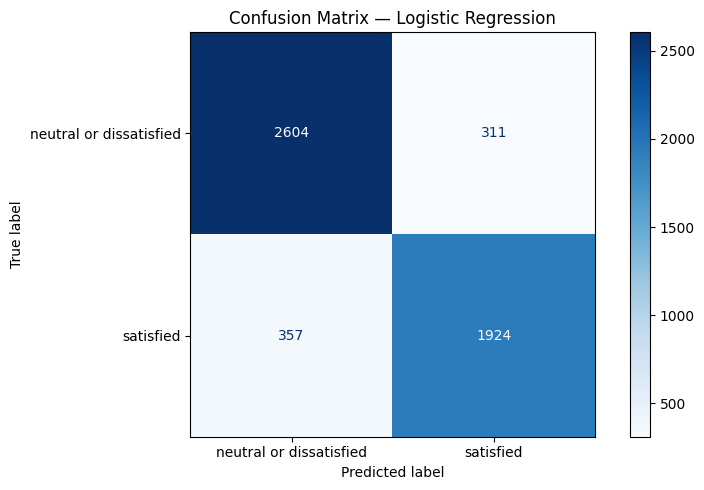


Top 10 features by |coefficient| (odds ratio = exp(coef)):
                          Feature  Coefficient  Odds Ratio
   Type of Travel_Personal Travel    -1.293893    0.274201
                  Online boarding     0.818763    2.267692
  Customer Type_disloyal Customer    -0.807130    0.446137
            Inflight wifi service     0.525405    1.691144
                  Checkin service     0.439553    1.552014
                 On-board service     0.316934    1.372913
                 Leg room service     0.314711    1.369864
                        Class_Eco    -0.313465    0.730910
           Ease of Online booking    -0.284904    0.752086
Departure/Arrival time convenient    -0.260726    0.770492


In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
trained_models['Logistic Regression'] = log_reg
_ = evaluate("Logistic Regression", log_reg, X_test_scaled, y_test)

# Interpret coefficients (odds ratios)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)
print("\nTop 10 features by |coefficient| (odds ratio = exp(coef)):")
print(coef_df.head(10).to_string(index=False))


**Interpretation:** A positive coefficient means a one-unit increase in that (scaled) feature
increases the odds of being classified `satisfied`; the odds ratio tells you the multiplicative
effect on the odds. Service-quality features like `Online boarding` and `Avg Service Score` are
expected to dominate here, consistent with the EDA scatter plots.